In [1]:
from pathlib import Path

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import xarray as xr
from context_flux_no.models.multiphysics import (
    AbstractMultiphysicsOperator,
    DPOT,
)
from context_flux_no.training.loader import (
    SegmentLoaderBackground,
)
from context_flux_no.training.trainer import Trainer
from jaxtyping import Array, Float, PRNGKeyArray

In [5]:
import h5py


datadir = Path("../../data")
with h5py.File(
    datadir
    / "datasets/euler_multi_quadrants_periodicBC/data/train/euler_multi_quadrants_periodicBC_gamma_1.3_CO2_20.hdf5",
    "r",
    page_buf_size=2 * 1024 * 1024,
    rdcc_nbytes=2 * 1024 * 1024,
) as file:
    fields = []
    for i in range(3):
        for k, v in file[f"t{i}_fields"].items():
            fields.append(v[0, 0:5])
    print(fields)


[array([[[0.998     , 0.998     , 0.998     , ..., 0.833     ,
         0.833     , 0.833     ],
        [0.998     , 0.998     , 0.998     , ..., 0.833     ,
         0.833     , 0.833     ],
        [0.998     , 0.998     , 0.998     , ..., 0.833     ,
         0.833     , 0.833     ],
        ...,
        [0.7832    , 0.7832    , 0.7832    , ..., 0.8408    ,
         0.8408    , 0.8408    ],
        [0.7832    , 0.7832    , 0.7832    , ..., 0.8408    ,
         0.8408    , 0.8408    ],
        [0.7832    , 0.7832    , 0.7832    , ..., 0.8408    ,
         0.8408    , 0.8408    ]],

       [[0.9153659 , 0.89752275, 0.8297719 , ..., 0.94964814,
         0.9366962 , 0.9239835 ],
        [0.9262198 , 0.9192131 , 0.8623156 , ..., 0.97415227,
         0.9579406 , 0.9398642 ],
        [0.94962835, 0.96321183, 0.93172175, ..., 0.9854637 ,
         0.9722462 , 0.95700896],
        ...,
        [0.807994  , 0.7734242 , 0.7563074 , ..., 1.0866851 ,
         0.9854859 , 0.9261457 ],
        [0.

In [ ]:
from the_well.data import WellDataset
from torch.util
dataset = WellDataset(
    well_base_path="../../data/datasets",
    well_dataset_name="euler_multi_quadrants_periodicBC",
    well_split_name="train",
    n_steps_input=4,
    n_steps_output=0,
    use_normalization=False,
)

In [ ]:
dataset[0]["input_fields"]

torch.Size([4, 512, 512, 5])

In [2]:
datadir = Path("../../data")
dataset_xr = xr.open_dataset(
    datadir / "euler_multi_quadrants_periodicBC_gamma_1.3_CO2_20_train.hdf5",
    engine="h5netcdf",
    chunks={},
).isel({"x": slice(None, None, 4), "y": slice(None, None, 4)})
dataset_xr

<xarray.Dataset> Size: 13GB
Dimensions:  (pde: 1, ic: 400, t: 101, dim: 5, x: 128, y: 128, param: 1)
Coordinates:
  * t        (t) float32 404B 0.0 1.0 2.0 3.0 4.0 ... 96.0 97.0 98.0 99.0 100.0
  * dim      (dim) <U8 160B 'density' 'energy' 'pressure' 'momentum' 'momentum'
  * x        (x) float32 512B 0.0 0.007828 0.01566 ... 0.9785 0.9863 0.9941
  * y        (y) float32 512B 0.0 0.007828 0.01566 ... 0.9785 0.9863 0.9941
  * param    (param) <U5 20B 'gamma'
Dimensions without coordinates: pde, ic
Data variables:
    values   (pde, ic, t, dim, x, y) float32 13GB dask.array<chunksize=(1, 400, 101, 5, 4, 4), meta=np.ndarray>
    coeffs   (pde, param) float64 8B dask.array<chunksize=(1, 1), meta=np.ndarray>

In [ ]:
dataset_xr["values"].isel({"ic": slice(0, 80)}).compute()

In [5]:
dataloader = SegmentLoaderBackground(
    dataset_xr, segment_length=11, batch_size=16, batches_per_load=20
)

In [ ]:
dataiter = iter(dataloader)
arr = next(dataiter)

In [5]:
(arr.dtype.itemsize * arr.size) / (1024 * 1024 * 1024)

0.859375

In [6]:
arr.shape

(16, 11, 5, 512, 512)

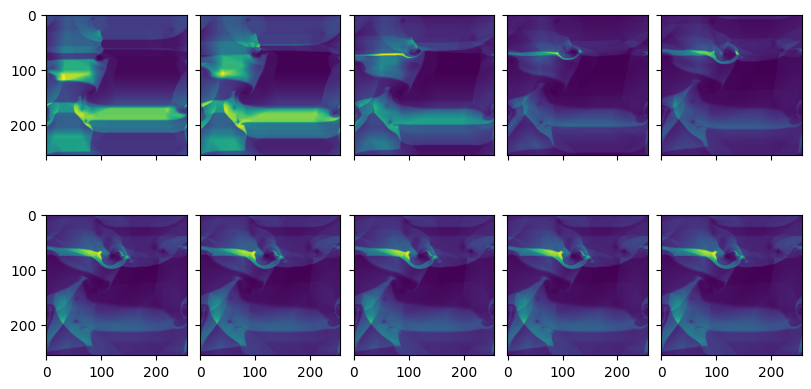

In [7]:
sample_idx = 0
fig, axes = plt.subplots(
    2, 5, figsize=(8, 4), constrained_layout=True, sharex=True, sharey=True
)
for i, ax in enumerate(axes.flat):
    ax.imshow(arr[sample_idx, 2 * i, 0, ::2, ::2])

In [8]:
arr.shape

(16, 11, 5, 512, 512)

In [8]:
import equinox as eqx
import jax
from context_flux_no.models.multiphysics import DPOT


dpot = DPOT(
    num_spatial_dims=2,
    in_channels=5,
    out_channels=5,
    in_timesteps=10,
    patch_size=(8, 8),
    img_size=(512, 512),
    embedding_dim=256,
    max_frequency_modes=(10, 10),
    fno_depth=5,
    num_blocks=4,
    num_classes=12,
    hidden_dim_patch=256,
    hidden_dim_fno=256,
    hidden_dim_output=32,
    key=jax.random.key(0),
)

In [12]:
eqx.filter_vmap(dpot)(arr[:, :-1])[0].block_until_ready()

Array([[[[ 0.12269744,  0.1182465 ,  0.13093485, ...,  0.13065633,
           0.12747036,  0.13149895],
         [ 0.11999622,  0.1281457 ,  0.13152269, ...,  0.12671871,
           0.11511075,  0.1357075 ],
         [ 0.13292617,  0.13422611,  0.12777561, ...,  0.12881742,
           0.12467884,  0.13942087],
         ...,
         [ 0.13518354,  0.12368563,  0.13243459, ...,  0.12939368,
           0.13412459,  0.12853138],
         [ 0.12193999,  0.14067186,  0.14645992, ...,  0.13198099,
           0.12891121,  0.12876587],
         [ 0.12056635,  0.12992394,  0.13414401, ...,  0.13177463,
           0.13274218,  0.11948536]],

        [[-0.12291457, -0.11910395, -0.105193  , ..., -0.11080626,
          -0.11922828, -0.12339735],
         [-0.11762524, -0.11467223, -0.11471288, ..., -0.10841621,
          -0.13761452, -0.1055356 ],
         [-0.11963731, -0.1068667 , -0.11402626, ..., -0.1194873 ,
          -0.11200091, -0.10990782],
         ...,
         [-0.10085297, -0.11395852

In [19]:
def loss_fn(
    model: AbstractMultiphysicsOperator,
    u: Float[Array, "batch time dim ..."],
    args,
    key: PRNGKeyArray,
) -> tuple[Float[Array, ""], dict]:
    u0, u1 = u[:, :-1], u[:, -1]
    keys = jax.random.split(key, u0.shape[0])
    u1_pred: Float[Array, "batch dim ..."] = eqx.filter_vmap(
        lambda u_, key_: model(u_, args, key=key_)
    )(u0, keys)[0]
    return jnp.mean((u1 - u1_pred) ** 2), dict()


trainer = Trainer(
    optax.adamw(1e-3),
    loss_fn,
    "./",
    None,
    {"entity": "jhko725", "project": "euler_test"},
    config_dict={"model": ""},
)

In [ ]:
trainer.train(dpot, dataloader, None, None, num_steps=500, seed=0)

Step: 1 | Train loss: 5.77877950668335 | Valid loss: 
            None
Step: 2 | Train loss: 5.997730255126953 | Valid loss: 
            None


Step: 3 | Train loss: 5.120358467102051 | Valid loss: 
            None


Step: 4 | Train loss: 1.5844664573669434 | Valid loss: 
            None


Step: 5 | Train loss: 1.7273378372192383 | Valid loss: 
            None


Step: 6 | Train loss: 1.9840843677520752 | Valid loss: 
            None


...

Step: 15 | Train loss: 0.9491835832595825 | Valid loss: 
            None


Step: 16 | Train loss: 0.7055436372756958 | Valid loss: 
            None


Step: 17 | Train loss: 0.3134033977985382 | Valid loss: 
            None


Step: 18 | Train loss: 0.4194553792476654 | Valid loss: 
            None


Step: 19 | Train loss: 0.3127429485321045 | Valid loss: 
            None
Step: 20 | Train loss: 0.46246176958084106 | Valid loss: 
            None
